In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
from statsmodels.tsa.stattools import adfuller

In [33]:
train = pd.read_csv('DailyDelhiClimateTrain.csv', parse_dates=['date'], index_col='date')
test = pd.read_csv('DailyDelhiClimateTest.csv', parse_dates=['date'], index_col='date')

In [34]:
#Установка частоты (Frequency)
train = train.ffill()
test = test.ffill()

In [35]:
print(train.head())
print(f"Кол-во строк: {len(train)}")

             meantemp   humidity  wind_speed  meanpressure
date                                                      
2013-01-01  10.000000  84.500000    0.000000   1015.666667
2013-01-02   7.400000  92.000000    2.980000   1017.800000
2013-01-03   7.166667  87.000000    4.633333   1018.666667
2013-01-04   8.666667  71.333333    1.233333   1017.166667
2013-01-05   6.000000  86.833333    3.700000   1016.500000
Кол-во строк: 1462


In [36]:
print(test.head())
print(f"Кол-во строк: {len(test)}")

             meantemp   humidity  wind_speed  meanpressure
date                                                      
2017-01-01  15.913043  85.869565    2.743478     59.000000
2017-01-02  18.500000  77.222222    2.894444   1018.277778
2017-01-03  17.111111  81.888889    4.016667   1018.333333
2017-01-04  18.700000  70.050000    4.545000   1015.700000
2017-01-05  18.388889  74.944444    3.300000   1014.333333
Кол-во строк: 114


In [37]:
y = train['meantemp']
y.index.freq = 'D'

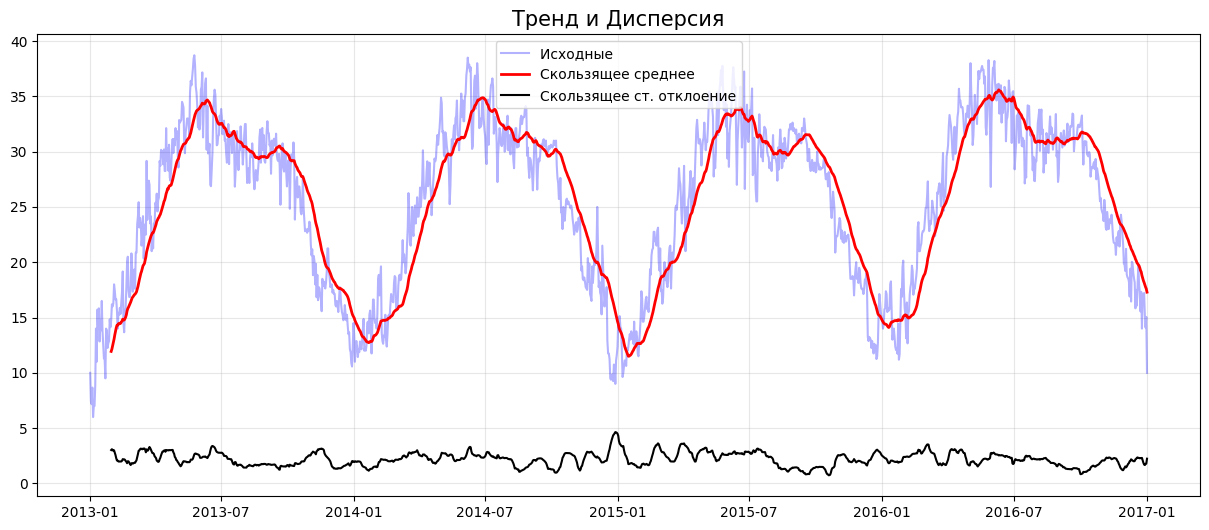

In [38]:
mean = y.rolling(window=30).mean()
std = y.rolling(window=30).std()
plt.figure(figsize=(15, 6))
plt.plot(y, color='blue', alpha=0.3, label='Исходные ')
plt.plot(mean, color='red', linewidth=2, label='Скользящее среднее')
plt.plot(std, color='black', linewidth=1.5, label='Скользящее ст. отклоение')

plt.title('Тренд и Дисперсия', fontsize=15)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
adft = adfuller(train['meantemp'])
print(f'ADF Statistic: {adft[0]:.4f}')
print(f'p-value: {adft[1]:.4f}')

ADF Statistic: -2.0211
p-value: 0.2774


/tmp/ipykernel_220/2782113918.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


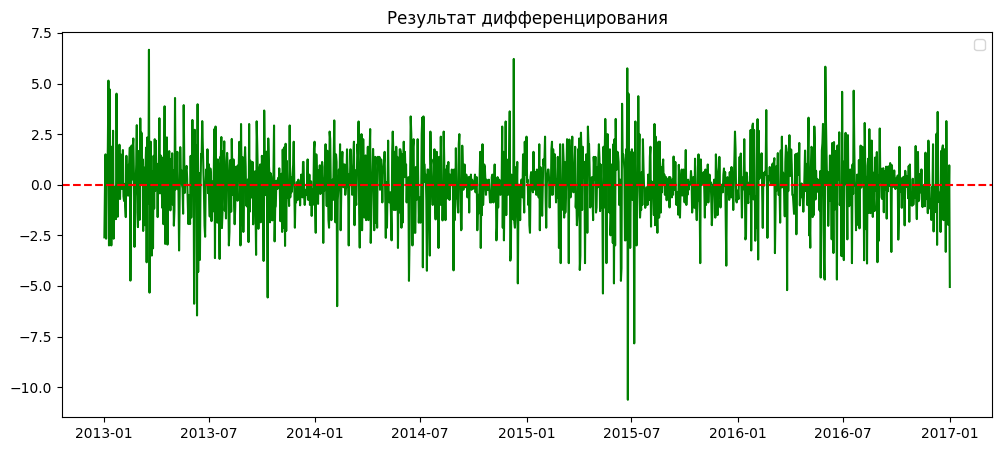

p-value после diff: 0.0000


In [40]:
y_diff = y.diff().dropna()

plt.figure(figsize=(12, 5))
plt.plot(y_diff, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Результат дифференцирования')
plt.legend()
plt.show()

res_diff = adfuller(y_diff)
print(f'p-value после diff: {res_diff[1]:.4f}')

In [41]:
# Модель AR(Авторегрессия) Будущее — это линейная комбинация прошлого.
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

df = pd.read_csv('DailyDelhiClimateTest.csv', parse_dates=['date'], index_col='date')
df = df.asfreq('D')

model_ar = ARIMA(y, order=(7, 1, 1)).fit()
pred_ar = model_ar.predict(start=test.index[0], end=test.index[-1])
rmse_ar = np.sqrt(mean_squared_error(test['meantemp'], pred_ar))

In [42]:
print(f"AR RMSE:  {np.sqrt(mean_squared_error(test['meantemp'], pred_ar)):.2f}")

AR RMSE:  10.71


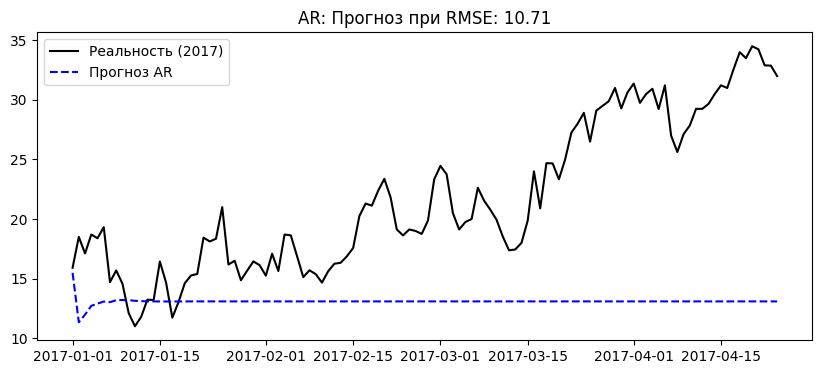

In [43]:
plt.figure(figsize=(10, 4))
plt.plot(test['meantemp'], label='Реальность (2017)', color='black')
plt.plot(pred_ar, label="Прогноз AR", color='blue', linestyle='--')
plt.title(f'AR: Прогноз при RMSE: {rmse_ar:.2f}')
plt.legend()
plt.show()

In [44]:
# Модель MA(Скользящее среднее)Прогноз строится на основе того, как сильно мы ошибались в предыдущие дни.
model_ma = ARIMA(y, order=(0, 1, 7)).fit()
pred_ma = model_ma.predict(start=test.index[0], end=test.index[-1])

In [45]:
rmse_ma = np.sqrt(mean_squared_error(test['meantemp'], pred_ma))
print(f"MA RMSE: {rmse_ma:.2f}")

MA RMSE: 10.71


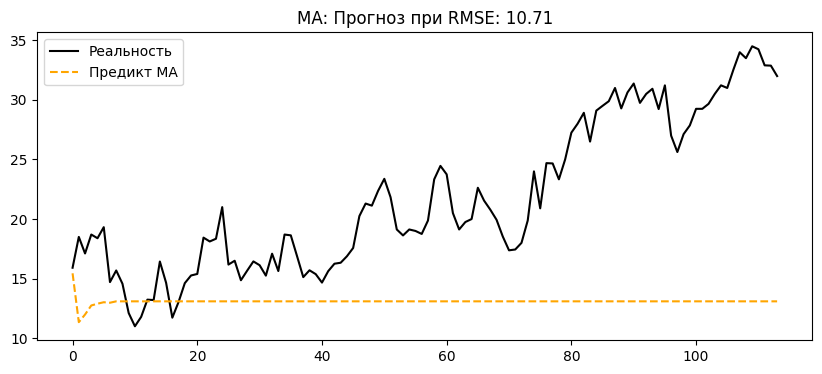

In [46]:
plt.figure(figsize=(10, 4))
plt.plot(test['meantemp'].values, label='Реальность', color='black')
plt.plot(pred_ma.values, label='Предикт MA', color='orange', linestyle='--')
plt.title(f'MA: Прогноз при RMSE: {rmse_ma:.2f}')
plt.legend()
plt.show()

In [47]:
# Модель ARIMA (классическая)
model_arima = ARIMA(y, order=(7, 1, 1)).fit()
pred_arima = model_arima.forecast(len(test))

In [48]:
rmse_arima = np.sqrt(mean_squared_error(test['meantemp'], pred_arima))
print(f"ARIMA RMSE: {rmse_arima:.2f}")

ARIMA RMSE: 10.71


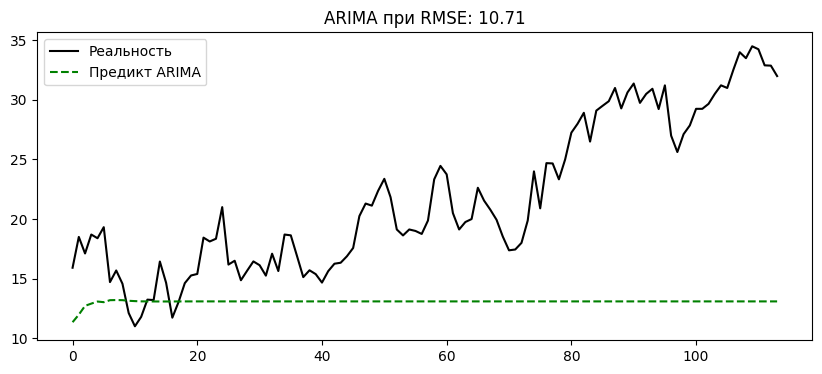

In [49]:
plt.figure(figsize=(10, 4))
plt.plot(test['meantemp'].values, label='Реальность', color='black')
plt.plot(pred_arima.values, label='Предикт ARIMA', color='green', linestyle='--')
plt.title(f'ARIMA при RMSE: {rmse_arima:.2f}')
plt.legend()
plt.show()

In [50]:
# Модель SARIMAX (сезонная)
# + сезонности
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(y, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)).fit(disp=False)
pred_sarima = model_sarima.forecast(len(test))

In [51]:
rmse_sarima = np.sqrt(mean_squared_error(test['meantemp'], pred_sarima))
print(f"SARIMA RMSE: {rmse_sarima:.2f}")

SARIMA RMSE: 10.42


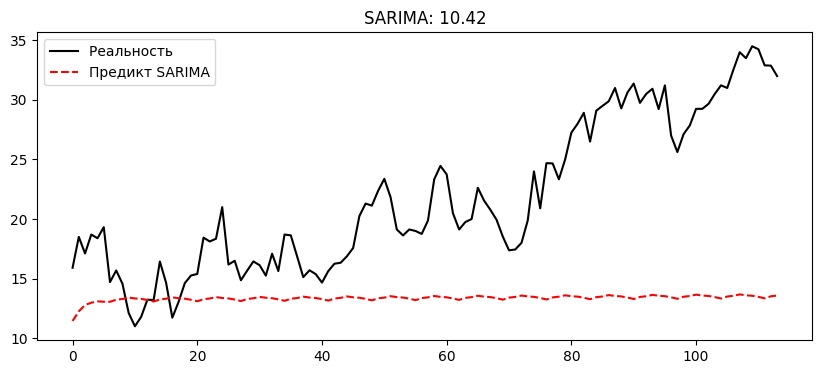

In [52]:
plt.figure(figsize=(10, 4))
plt.plot(test['meantemp'].values, label='Реальность ', color='black')
plt.plot(pred_sarima.values, label='Предикт SARIMA', color='red', linestyle='--')
plt.title(f'SARIMA: {rmse_sarima:.2f}')
plt.legend()
plt.show()

In [53]:
# Модель SARIMAX (температура + влажность)
exog_train = train[['humidity', 'wind_speed']]
exog_test = test[['humidity', 'wind_speed']]

In [54]:
model_sarima2 = SARIMAX(y, exog=exog_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)).fit(disp=False)
pred_sarims2 = model_sarima2.forecast(len(test), exog=exog_test)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [55]:
rmse_sarima2 = np.sqrt(mean_squared_error(test['meantemp'], pred_sarims2))
print(f"SARIMAX (H + W) RMSE: {rmse_sarima2:.2f}")

SARIMAX (H + W) RMSE: 5.98


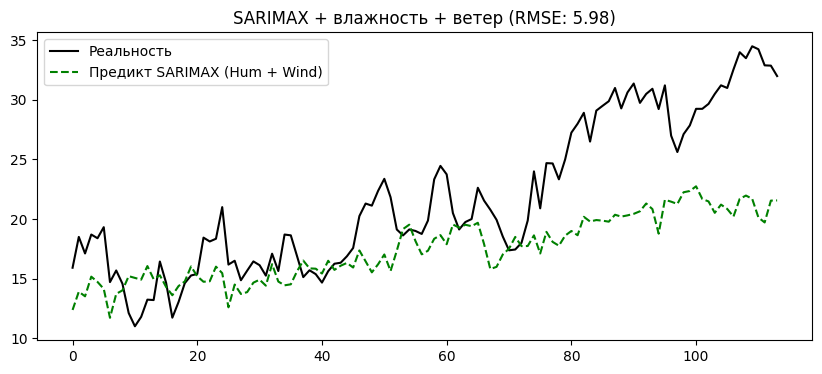

In [56]:
plt.figure(figsize=(10, 4))
plt.plot(test['meantemp'].values, label='Реальность', color='black')
plt.plot(pred_sarims2.values, label='Предикт SARIMAX (Hum + Wind)', color='green', linestyle='--')
plt.title(f'SARIMAX + влажность + ветер (RMSE: {rmse_sarima2:.2f})')
plt.legend()
plt.show()

In [57]:
#Автоподбор параметров (Auto-ARIMA)
!pip install pmdarima

In [59]:
import pmdarima as pm

auto_model = pm.auto_arima(y,
                           exogenous=train[['humidity']],
                           seasonal=True, m=7,
                           stepwise=True,
                           suppress_warnings=True,
                           error_action="ignore")

print(f"Лучшие параметры: {auto_model.order} x {auto_model.seasonal_order}")

Лучшие параметры: (1, 1, 1) x (0, 0, 0, 7)


In [60]:
model_best = auto_model.fit(y, exogenous=train[['humidity']])
pred_best = model_best.predict(n_periods=len(test), exogenous=test[['humidity']])

In [61]:
rmse_best = np.sqrt(mean_squared_error(test['meantemp'], pred_best))
print(f"RMSE Auto-ARIMA: {rmse_best:.2f}")

RMSE Auto-ARIMA: 10.65


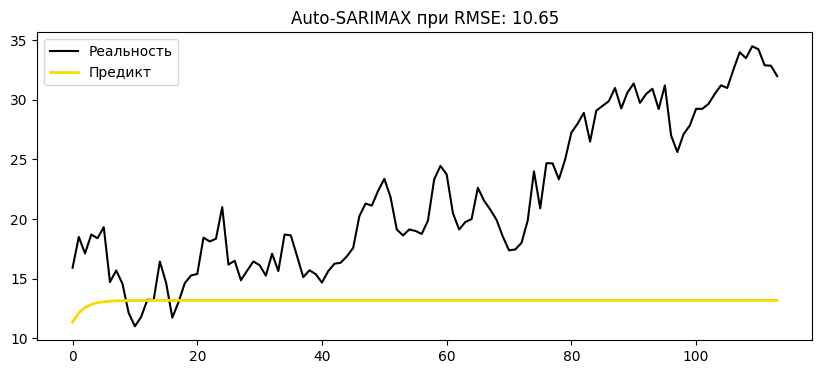

In [62]:
plt.figure(figsize=(10, 4))
plt.plot(test['meantemp'].values, label='Реальность', color='black')
plt.plot(pred_best.values, label='Предикт', color='gold', linewidth=2)
plt.title(f'Auto-SARIMAX при RMSE: {rmse_best:.2f}')
plt.legend()
plt.show()